$\text{Another application of langrange's equation}$

In [37]:
import numpy as np
import sympy as smp
import matplotlib.pyplot as plt
from matplotlib import animation
from scipy.integrate import odeint

![alt text](image.png)

In [38]:
t, g, l1, l2, m1, m2, m3, k, L0 = smp.symbols('t g l_1 l_2 m_1 m_2 m_3 k L_0')
the1, the2 = smp.symbols(r'theta_1 theta_2', cls=smp.Function)

In [39]:
the1 = the1(t)
the2 = the2(t)
the1_d = smp.diff(the1, t)
the2_d = smp.diff(the2, t) 
the1_dd = smp.diff(the1_d, t)
the2_dd = smp.diff(the2_d, t)

In [40]:
x1 = l1 * smp.cos(the1)
y1 = - l1 * smp.sin(the1)
x2 = 2 * x1
y2 = 0
x3 = x2 + l2 * smp.sin(the2)
y3 = - l2 * smp.cos(the2)

In [41]:
T = smp.Rational(1, 2) * m1 * (smp.diff(x1, t)**2 + smp.diff(y1, t)**2) + smp.Rational(1, 2) * m2 * (smp.diff(x2, t)**2 + smp.diff(y2, t)**2) + smp.Rational(1, 2) * m3 * (smp.diff(x3, t)**2 + smp.diff(y3, t)**2)
V = m1 * g * y1 + m2 * g * y2 + m3 * g * y3 + smp.Rational(1, 2) * k * (x2 - L0)**2
L = T - V

In [42]:
L

g*l_1*m_1*sin(theta_1(t)) + g*l_2*m_3*cos(theta_2(t)) - k*(-L_0 + 2*l_1*cos(theta_1(t)))**2/2 + 2*l_1**2*m_2*sin(theta_1(t))**2*Derivative(theta_1(t), t)**2 + m_1*(l_1**2*sin(theta_1(t))**2*Derivative(theta_1(t), t)**2 + l_1**2*cos(theta_1(t))**2*Derivative(theta_1(t), t)**2)/2 + m_3*(l_2**2*sin(theta_2(t))**2*Derivative(theta_2(t), t)**2 + (-2*l_1*sin(theta_1(t))*Derivative(theta_1(t), t) + l_2*cos(theta_2(t))*Derivative(theta_2(t), t))**2)/2

$Langrange's\ Equation:$
$$\frac{\partial L}{\partial \theta_1} - \frac{d}{dt} \left( \frac{\partial L}{\partial \dot{\theta_1}} \right) = 0$$
$$\frac{\partial L}{\partial \theta_2} - \frac{d}{dt} \left( \frac{\partial L}{\partial \dot{\theta_2}} \right) = 0$$

In [43]:
LE1 = smp.diff(L, the1) - smp.diff(smp.diff(L, the1_d), t).simplify()
LE2 = smp.diff(L, the2) - smp.diff(smp.diff(L, the2_d), t).simplify()

In [44]:
LE1

g*l_1*m_1*cos(theta_1(t)) + 2*k*l_1*(-L_0 + 2*l_1*cos(theta_1(t)))*sin(theta_1(t)) + 4*l_1**2*m_2*sin(theta_1(t))*cos(theta_1(t))*Derivative(theta_1(t), t)**2 - 2*l_1*m_3*(-2*l_1*sin(theta_1(t))*Derivative(theta_1(t), t) + l_2*cos(theta_2(t))*Derivative(theta_2(t), t))*cos(theta_1(t))*Derivative(theta_1(t), t) - l_1*(l_1*m_1*Derivative(theta_1(t), (t, 2)) + 4*l_1*m_2*sin(theta_1(t))**2*Derivative(theta_1(t), (t, 2)) + 4*l_1*m_2*sin(2*theta_1(t))*Derivative(theta_1(t), t)**2 + 2*m_3*(2*l_1*sin(theta_1(t))*Derivative(theta_1(t), t) - l_2*cos(theta_2(t))*Derivative(theta_2(t), t))*cos(theta_1(t))*Derivative(theta_1(t), t) + 2*m_3*(2*l_1*sin(theta_1(t))*Derivative(theta_1(t), (t, 2)) + 2*l_1*cos(theta_1(t))*Derivative(theta_1(t), t)**2 + l_2*sin(theta_2(t))*Derivative(theta_2(t), t)**2 - l_2*cos(theta_2(t))*Derivative(theta_2(t), (t, 2)))*sin(theta_1(t)))

In [45]:
LE2

-g*l_2*m_3*sin(theta_2(t)) - l_2*m_3*(2*l_1*sin(theta_1(t))*sin(theta_2(t))*Derivative(theta_1(t), t)*Derivative(theta_2(t), t) - 2*l_1*sin(theta_1(t))*cos(theta_2(t))*Derivative(theta_1(t), (t, 2)) - 2*l_1*cos(theta_1(t))*cos(theta_2(t))*Derivative(theta_1(t), t)**2 + l_2*Derivative(theta_2(t), (t, 2))) + m_3*(2*l_2**2*sin(theta_2(t))*cos(theta_2(t))*Derivative(theta_2(t), t)**2 - 2*l_2*(-2*l_1*sin(theta_1(t))*Derivative(theta_1(t), t) + l_2*cos(theta_2(t))*Derivative(theta_2(t), t))*sin(theta_2(t))*Derivative(theta_2(t), t))/2

In [46]:
sols = smp.solve([LE1, LE2], (the1_dd, the2_dd), simplify=False, rational=False)

In [47]:
sols[the1_dd]

2*L_0*k*sin(theta_1(t))/(-l_1*m_1 - 4*l_1*m_2*sin(theta_1(t))**2 + 4*l_1*m_3*sin(theta_1(t))**2*cos(theta_2(t))**2 - 4*l_1*m_3*sin(theta_1(t))**2) - g*m_1*cos(theta_1(t))/(-l_1*m_1 - 4*l_1*m_2*sin(theta_1(t))**2 + 4*l_1*m_3*sin(theta_1(t))**2*cos(theta_2(t))**2 - 4*l_1*m_3*sin(theta_1(t))**2) + 2*g*m_3*sin(theta_1(t))*sin(theta_2(t))*cos(theta_2(t))/(-l_1*m_1 - 4*l_1*m_2*sin(theta_1(t))**2 + 4*l_1*m_3*sin(theta_1(t))**2*cos(theta_2(t))**2 - 4*l_1*m_3*sin(theta_1(t))**2) - 4*k*l_1*sin(theta_1(t))*cos(theta_1(t))/(-l_1*m_1 - 4*l_1*m_2*sin(theta_1(t))**2 + 4*l_1*m_3*sin(theta_1(t))**2*cos(theta_2(t))**2 - 4*l_1*m_3*sin(theta_1(t))**2) - 4*l_1*m_2*sin(theta_1(t))*cos(theta_1(t))*Derivative(theta_1(t), t)**2/(-l_1*m_1 - 4*l_1*m_2*sin(theta_1(t))**2 + 4*l_1*m_3*sin(theta_1(t))**2*cos(theta_2(t))**2 - 4*l_1*m_3*sin(theta_1(t))**2) + 4*l_1*m_2*sin(2*theta_1(t))*Derivative(theta_1(t), t)**2/(-l_1*m_1 - 4*l_1*m_2*sin(theta_1(t))**2 + 4*l_1*m_3*sin(theta_1(t))**2*cos(theta_2(t))**2 - 4*l_1*m_3*si

In [48]:
sols[the2_dd]

4*L_0*k*sin(theta_1(t))**2*cos(theta_2(t))/(-l_2*m_1 - 4*l_2*m_2*sin(theta_1(t))**2 + 4*l_2*m_3*sin(theta_1(t))**2*cos(theta_2(t))**2 - 4*l_2*m_3*sin(theta_1(t))**2) - 2*g*m_1*sin(theta_1(t))*cos(theta_1(t))*cos(theta_2(t))/(-l_2*m_1 - 4*l_2*m_2*sin(theta_1(t))**2 + 4*l_2*m_3*sin(theta_1(t))**2*cos(theta_2(t))**2 - 4*l_2*m_3*sin(theta_1(t))**2) + g*m_1*sin(theta_2(t))/(-l_2*m_1 - 4*l_2*m_2*sin(theta_1(t))**2 + 4*l_2*m_3*sin(theta_1(t))**2*cos(theta_2(t))**2 - 4*l_2*m_3*sin(theta_1(t))**2) + 4*g*m_2*sin(theta_1(t))**2*sin(theta_2(t))/(-l_2*m_1 - 4*l_2*m_2*sin(theta_1(t))**2 + 4*l_2*m_3*sin(theta_1(t))**2*cos(theta_2(t))**2 - 4*l_2*m_3*sin(theta_1(t))**2) + 4*g*m_3*sin(theta_1(t))**2*sin(theta_2(t))/(-l_2*m_1 - 4*l_2*m_2*sin(theta_1(t))**2 + 4*l_2*m_3*sin(theta_1(t))**2*cos(theta_2(t))**2 - 4*l_2*m_3*sin(theta_1(t))**2) - 8*k*l_1*sin(theta_1(t))**2*cos(theta_1(t))*cos(theta_2(t))/(-l_2*m_1 - 4*l_2*m_2*sin(theta_1(t))**2 + 4*l_2*m_3*sin(theta_1(t))**2*cos(theta_2(t))**2 - 4*l_2*m_3*sin(th

$$\text{Let } z_1 = \frac{d \theta_1}{dt} \text{ and } z_2 = \frac{d \theta_2}{dt}$$
$$\text{then } \frac{dz_1}{dt} = \frac{d^2 \theta_1}{dt^2} \text{ and } \frac{dz_2}{dt} = \frac{d^2 \theta_2}{dt^2}$$

In [49]:
dz1dt_f = smp.lambdify((t, g, k, L0, m1, m2, m3, l1, l2, the1, the2, the1_d, the2_d), sols[the1_dd])
dz2dt_f = smp.lambdify((t, g, k, L0, m1, m2, m3, l1, l2, the1, the2, the1_d, the2_d), sols[the2_dd])
dthe1dt_f = smp.lambdify(the1_d, the1_d)
dthe2dt_f = smp.lambdify(the2_d, the2_d)

Now $\vec{S} = (\theta_1, z_1, \theta_2, z_2)$

In [50]:
def dSdt(S, t, g, k, L0, m1, m2, m3, l1, l2):
    the1, z1, the2, z2 = S
    return [
        dthe1dt_f(z1),
        dz1dt_f(t, g, k, L0, m1, m2, m3, l1, l2, the1, the2, z1, z2),
        dthe2dt_f(z2),
        dz2dt_f(t, g, k, L0, m1, m2, m3, l1, l2, the1, the2, z1, z2)
    ]
    

In [51]:
t = np.linspace(0, 40, 1001)
g = 9.81
k = 30 
m1 = 2
m2 = 2
m3 = 1
l1 = 1
l2 = 1
L0 = 1.5*l1
ans = odeint(dSdt, y0=[1, -1, -1, 1], t=t, args=(g, k, L0, m1, m2, m3, l1, l2))

In [55]:
the1 = ans.T[0]
the2 = ans.T[2]

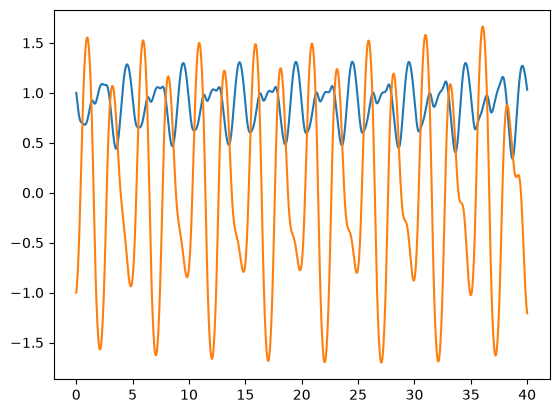

In [56]:
plt.plot(t, the1)
plt.plot(t, the2)

In [58]:
def getx1y1x2y2x3y3(t, the1, the2, l1, l2):
    return (
        l1 * np.cos(the1),
        - l1 * np.sin(the1),
        2 * l1 * np.cos(the1),
        np.zeros(len(the1)),
        2 * l1 * np.cos(the1) + l2 * np.sin(the2),
        - l2 * np.cos(the2)
    )
x1, y1, x2, y2, x3, y3 = getx1y1x2y2x3y3(t, ans.T[0], ans.T[2], l1, l2)

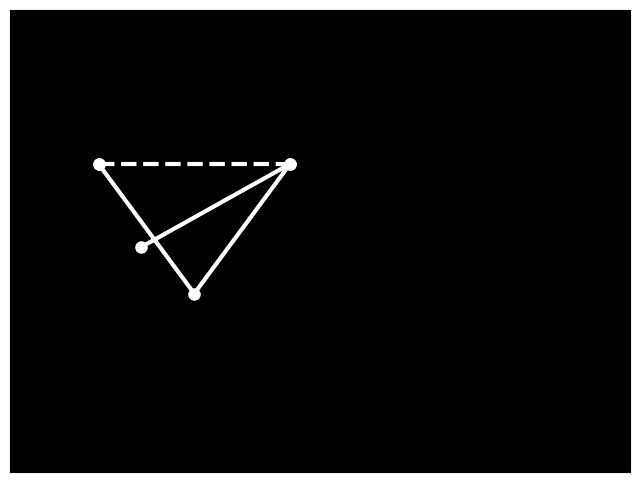

In [66]:
def animate(i):
    line1.set_data([0, x1[i], x2[i], x3[i]], [0, y1[i], y2[i], y3[i]])
    line2.set_data([0, x2[i]], [0, y2[i]])

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.set_facecolor('black')
ax.set_xlim(-0.5, 3)
ax.set_ylim(-2, 1)
line1, = ax.plot([], [], 'o-', lw=3, color='white', markersize=8)
line2, = ax.plot([], [], 'o--', lw=3, color='white', markersize=8)   
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

ani = animation.FuncAnimation(fig, animate, frames=1000, interval=50)
ani.save('LE3.gif', writer='pillow', fps=25)

Do check out the gif file named LE3.gif inside media folder